# California Housing






In [1]:
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing(as_frame=True)

# Access the features (X) and target (y)
df = housing.frame
print(df.head())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [2]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


1. controllare che min e max abbiano senso (AveRooms e anche AveOccup con min e max fuori scala)
2. rapporto tra media e dev std. Se è maggiore di 1, c'è una forte dispersione di dati su quella colonna (AveOccup e Population)
3. se media e 50% sono simili tra loro, se non lo sono abbiamo una distribuzione chiamata skewed (se media << 50% applico una trasformazione logaritmica per bilanciare)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


1. Controllare le colonne che hanno dei null
2. Controllare le colonne che non sono numeri, perchè la matematica non sa gestire le stringhe


## gestione valori nulli

- se nulli < 5% rimuovo righe nulle
- se nulli < 15/20% sostituisco con medie i numeri e moda le stringhe
- se nulli > 20% o elimino colonna o creo un modello di machine learning per predirre i nulli

### sostituzione con media
immaginiamo un dataset con età e guadagno, ho il 10% dei nulli sul guadagno
raggruppo in fasce d' età e faccio la media di ogni fascia, sostituisco i nulli del guadagno in base all' età associata

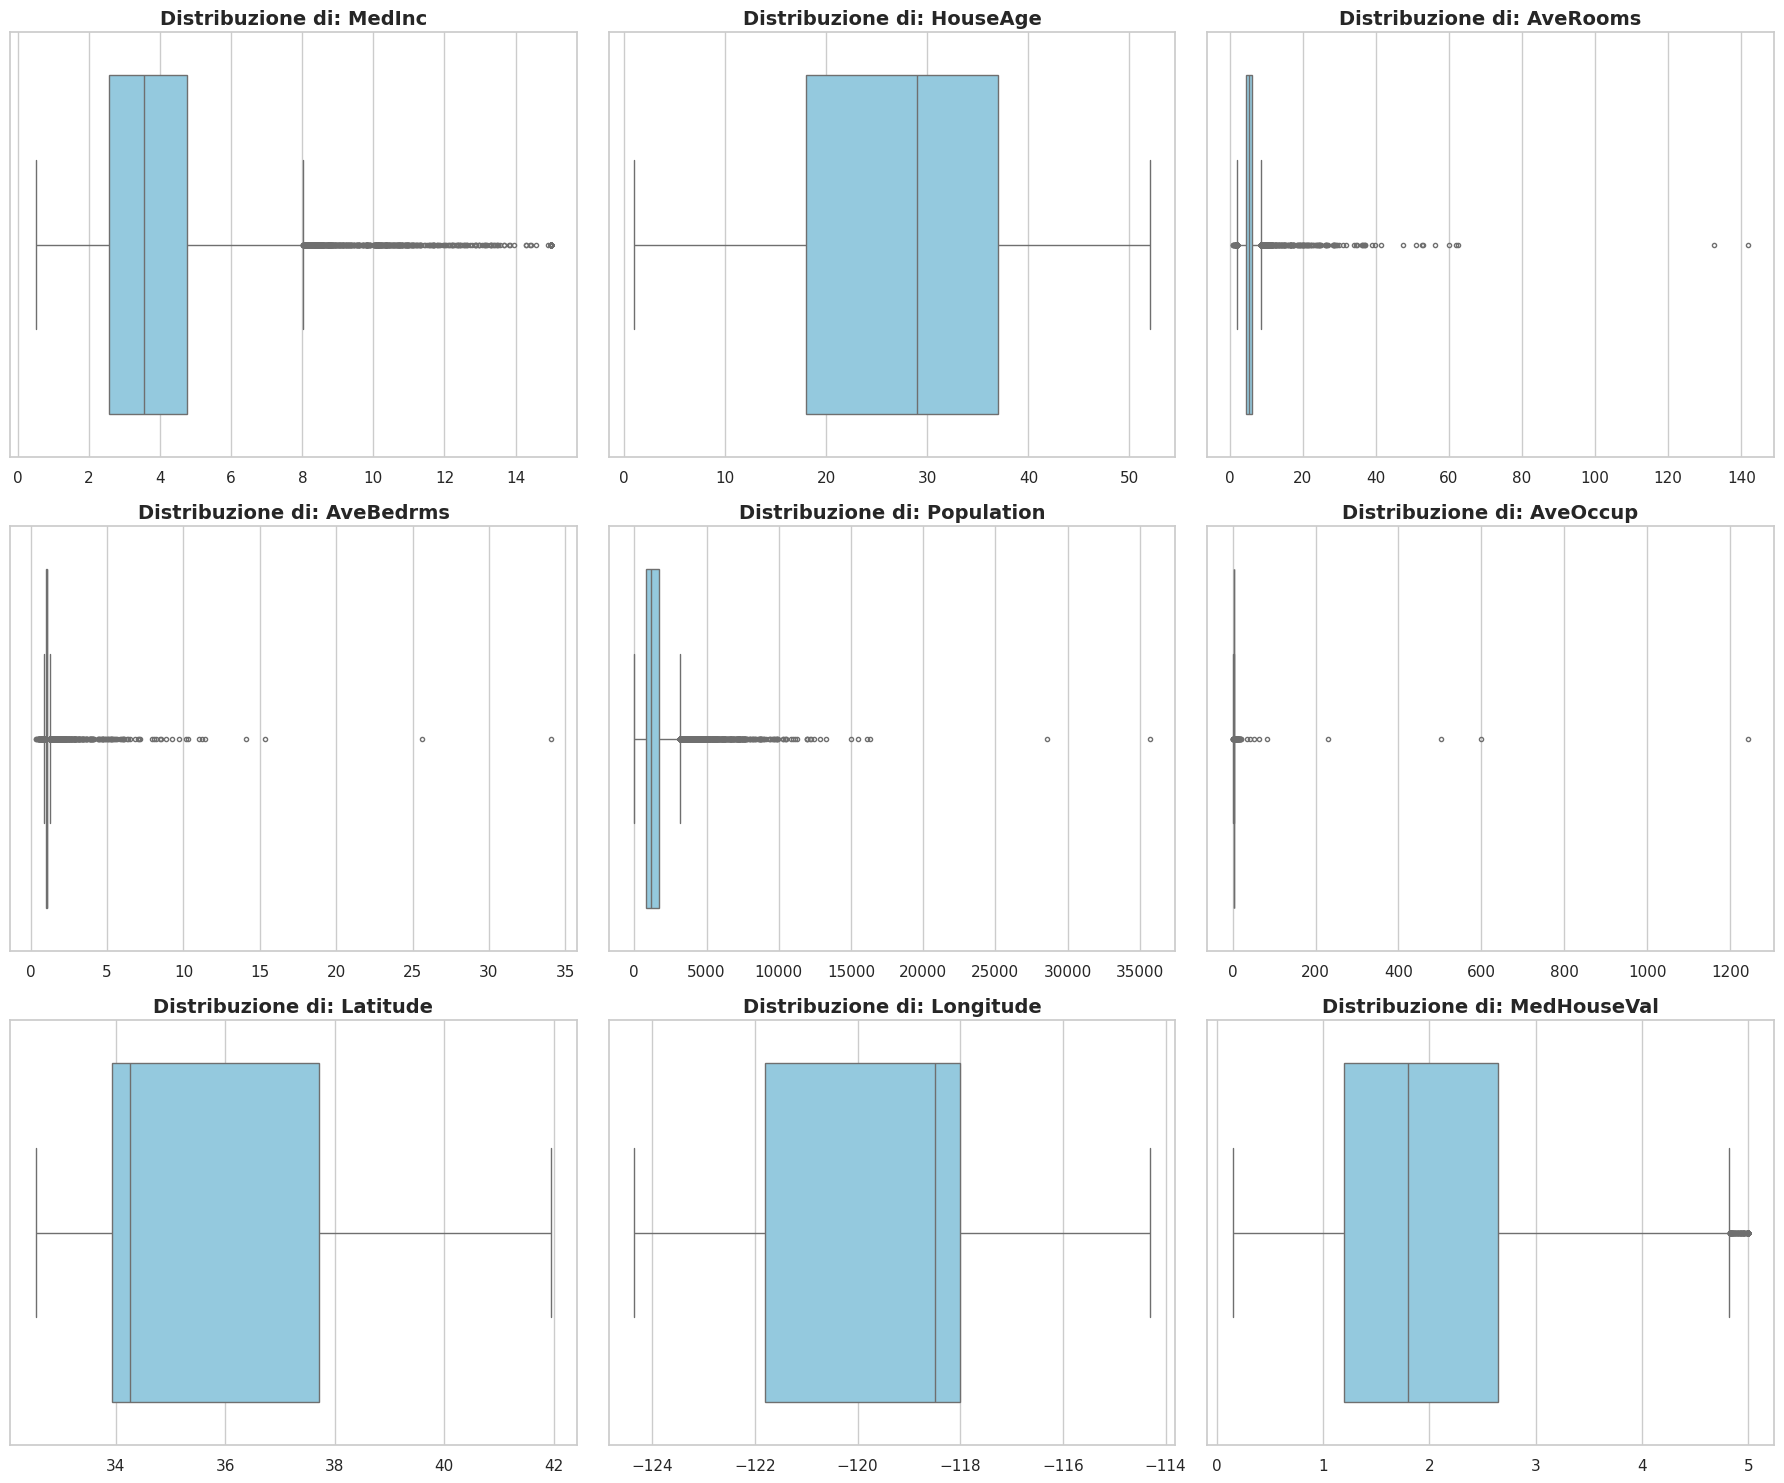

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Impostiamo lo stile e la griglia
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten() # Appiattiamo la matrice di assi per iterare facilmente

# 3. Ciclo per creare un boxplot per ogni colonna
for i, col in enumerate(df.columns):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('') # Rimuoviamo l'etichetta x per pulizia

# 4. Ottimizzazione del layout
plt.tight_layout()
plt.show()

### cosa rappresentano le linee verticali del boxplot?
 Le linee verticali rappresentano i valori minimi e massimi (non anomali) dei dati in ogni colonna.

e la parte blu del boxplot?


La parte blu del boxplot rappresenta l'intervallo interquartile (IQR), quindi il 50% centrale dei dati.


La linea all'interno del box rappresenta la mediana.


i pallini sono gli outlier

## outliers
gli outliers possono essere di due tipi:
- caso statisticamente raro (persona alta 2,30m)
- errore di inserimento(persona alta 23m)

## Cosa mi devo chiedere?

- perché ci sono così tanti outliers?
- ci sono degli outlier estremi? Da cosa sono dovuti?

# Se decido di rimuovere gli outlier per pulire il dataset (non sempre vanno puliti gli outlier)

### 1. Metodo IQR (Interquartile Range)

È la tecnica usata dai **boxplot**. Si basa sulla distanza tra il primo quartile ($Q_1$) e il terzo quartile ($Q_3$). 
Tutto ciò che cade fuori dall'intervallo $[Q_1 - 1.5 \times IQR, Q_3 + 1.5 \times IQR]$ viene considerato outlier.

In [5]:
def remove_outliers_iqr(data, columns):
    df_clean = data.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

# Filtraggio
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

# Applichiamolo solo ad alcune colonne critiche (es. MedInc e AveRooms)
df_iqr = remove_outliers_iqr(df, ['MedInc', 'AveRooms', 'AveOccup'])
print(f"Righe rimosse con IQR: {len(df) - len(df_iqr)}")

Righe rimosse con IQR: 711


### 2. Metodo Z-Score (Deviazione Standard)

Questa tecnica si basa sulla distribuzione normale. Si calcola quanto un valore dista dalla media in termini di deviazioni standard ($\sigma$). La formula dello Z-score è:

$$Z = \frac{x - \mu}{\sigma}$$

Solitamente, un valore con uno **Z-score maggiore di 3 o minore di -3** è considerato un outlier estremo (rappresenta meno dello 0.3% dei dati in una distribuzione normale).

In [6]:
import numpy as np
from scipy import stats

def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata
    z_scores = np.abs(stats.zscore(df_clean[columns]))

    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# Applicazione
df_zscore = remove_outliers_zscore(df, ['MedInc', 'AveRooms', 'AveOccup'])
print(f"Righe rimosse con Z-Score: {len(df) - len(df_zscore)}")

Righe rimosse con Z-Score: 482


IQR è più aggressivo ma funziona bene anche su distribuzioni più sporche 

Z-SCORE meno aggressivo ma funziona solo su dati distribuiti normalmente

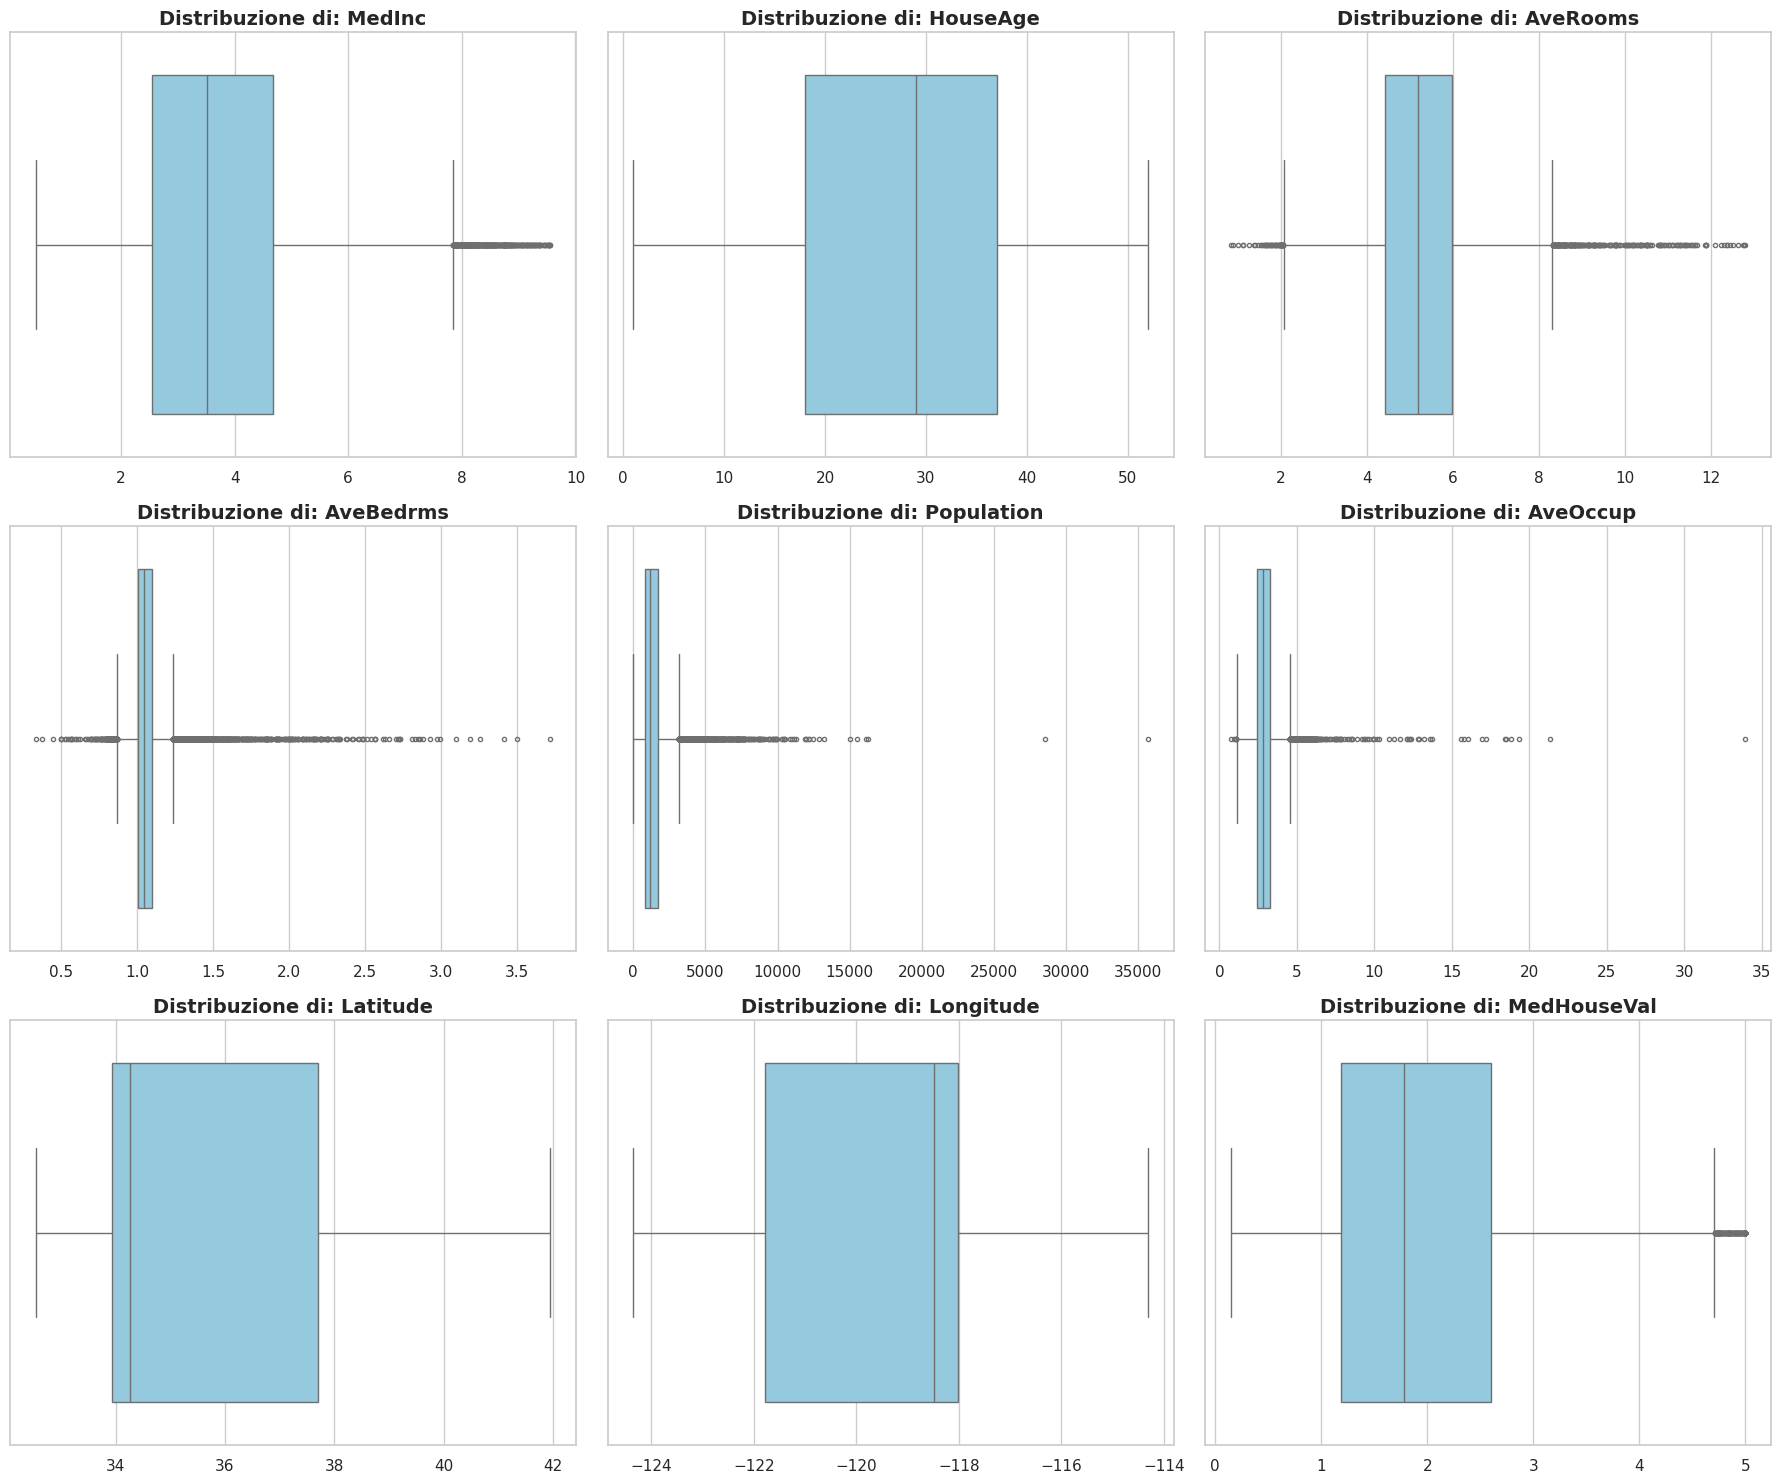

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Impostiamo lo stile e la griglia
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten() # Appiattiamo la matrice di assi per iterare facilmente

# 3. Ciclo per creare un boxplot per ogni colonna
for i, col in enumerate(df_zscore.columns):
    sns.boxplot(x=df_zscore[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('') # Rimuoviamo l'etichetta x per pulizia

# 4. Ottimizzazione del layout
plt.tight_layout()
plt.show()

## colonne categoriche

se la colonna è binaria (si/no, True/False) trasformiamo in 0,1

se ho più variabili (Milano, Roma, Napoli) assegno a ogni variabile un numero (Milano:1, Roma:2, Napoli:3)

ma qui sorge un problema: con la nuova configurazione per il computer Milano + Roma = Napoli, non posso quindi applicarla su variabili scollegate

se avessi piccolo-medio-grande che hanno un rapporto di grandezza potrei farlo ma se sono scollegate devo procedere diversamente

creo una colonna binaria per ogni opzione:

nuova colonna: is_Milano che contiene True o False ossia 0 o 1, is_Roma, is_Napoli (attenzione che se ho 100 opzioni sto aggiungendo 100 dimensioni)

### 1. Label Encoding

Il `LabelEncoder` trasforma le stringhe in numeri progressivi ($0, 1, 2, ...$).

In [8]:
from sklearn.preprocessing import LabelEncoder

# Esempio: Target con tre classi
y = ['Basso', 'Medio', 'Alto', 'Basso', 'Alto']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Classi originali: {le.classes_}")
print(f"Valori trasformati: {y_encoded}")
# Output: [1, 2, 0, 1, 0] (l'ordine è spesso alfabetico)

Classi originali: ['Alto' 'Basso' 'Medio']
Valori trasformati: [1 2 0 1 0]


### 2. One-Hot Encoding

Questa è la tecnica standard per le variabili categoriche senza un ordine intrinseco (es. "Colore", "Città"). Crea una nuova colonna binaria ($0$ o $1$) per ogni categoria.

In [9]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# DataFrame di esempio
df_test = pd.DataFrame({'Città': ['Roma', 'Milano', 'Napoli', 'Roma']})

# Inizializziamo l'encoder
# sparse_output=False serve per avere un array NumPy leggibile (non una matrice sparsa)
ohe = OneHotEncoder(sparse_output=False)

# Trasformazione
ohe_transformed = ohe.fit_transform(df_test[['Città']])

# Creiamo un nuovo DataFrame con i nomi delle colonne corretti
df_ohe = pd.DataFrame(ohe_transformed, columns=ohe.get_feature_names_out(['Città']))

print(df_ohe)

   Città_Milano  Città_Napoli  Città_Roma
0           0.0           0.0         1.0
1           1.0           0.0         0.0
2           0.0           1.0         0.0
3           0.0           0.0         1.0


## visualizziamo distribuzioni delle colonne

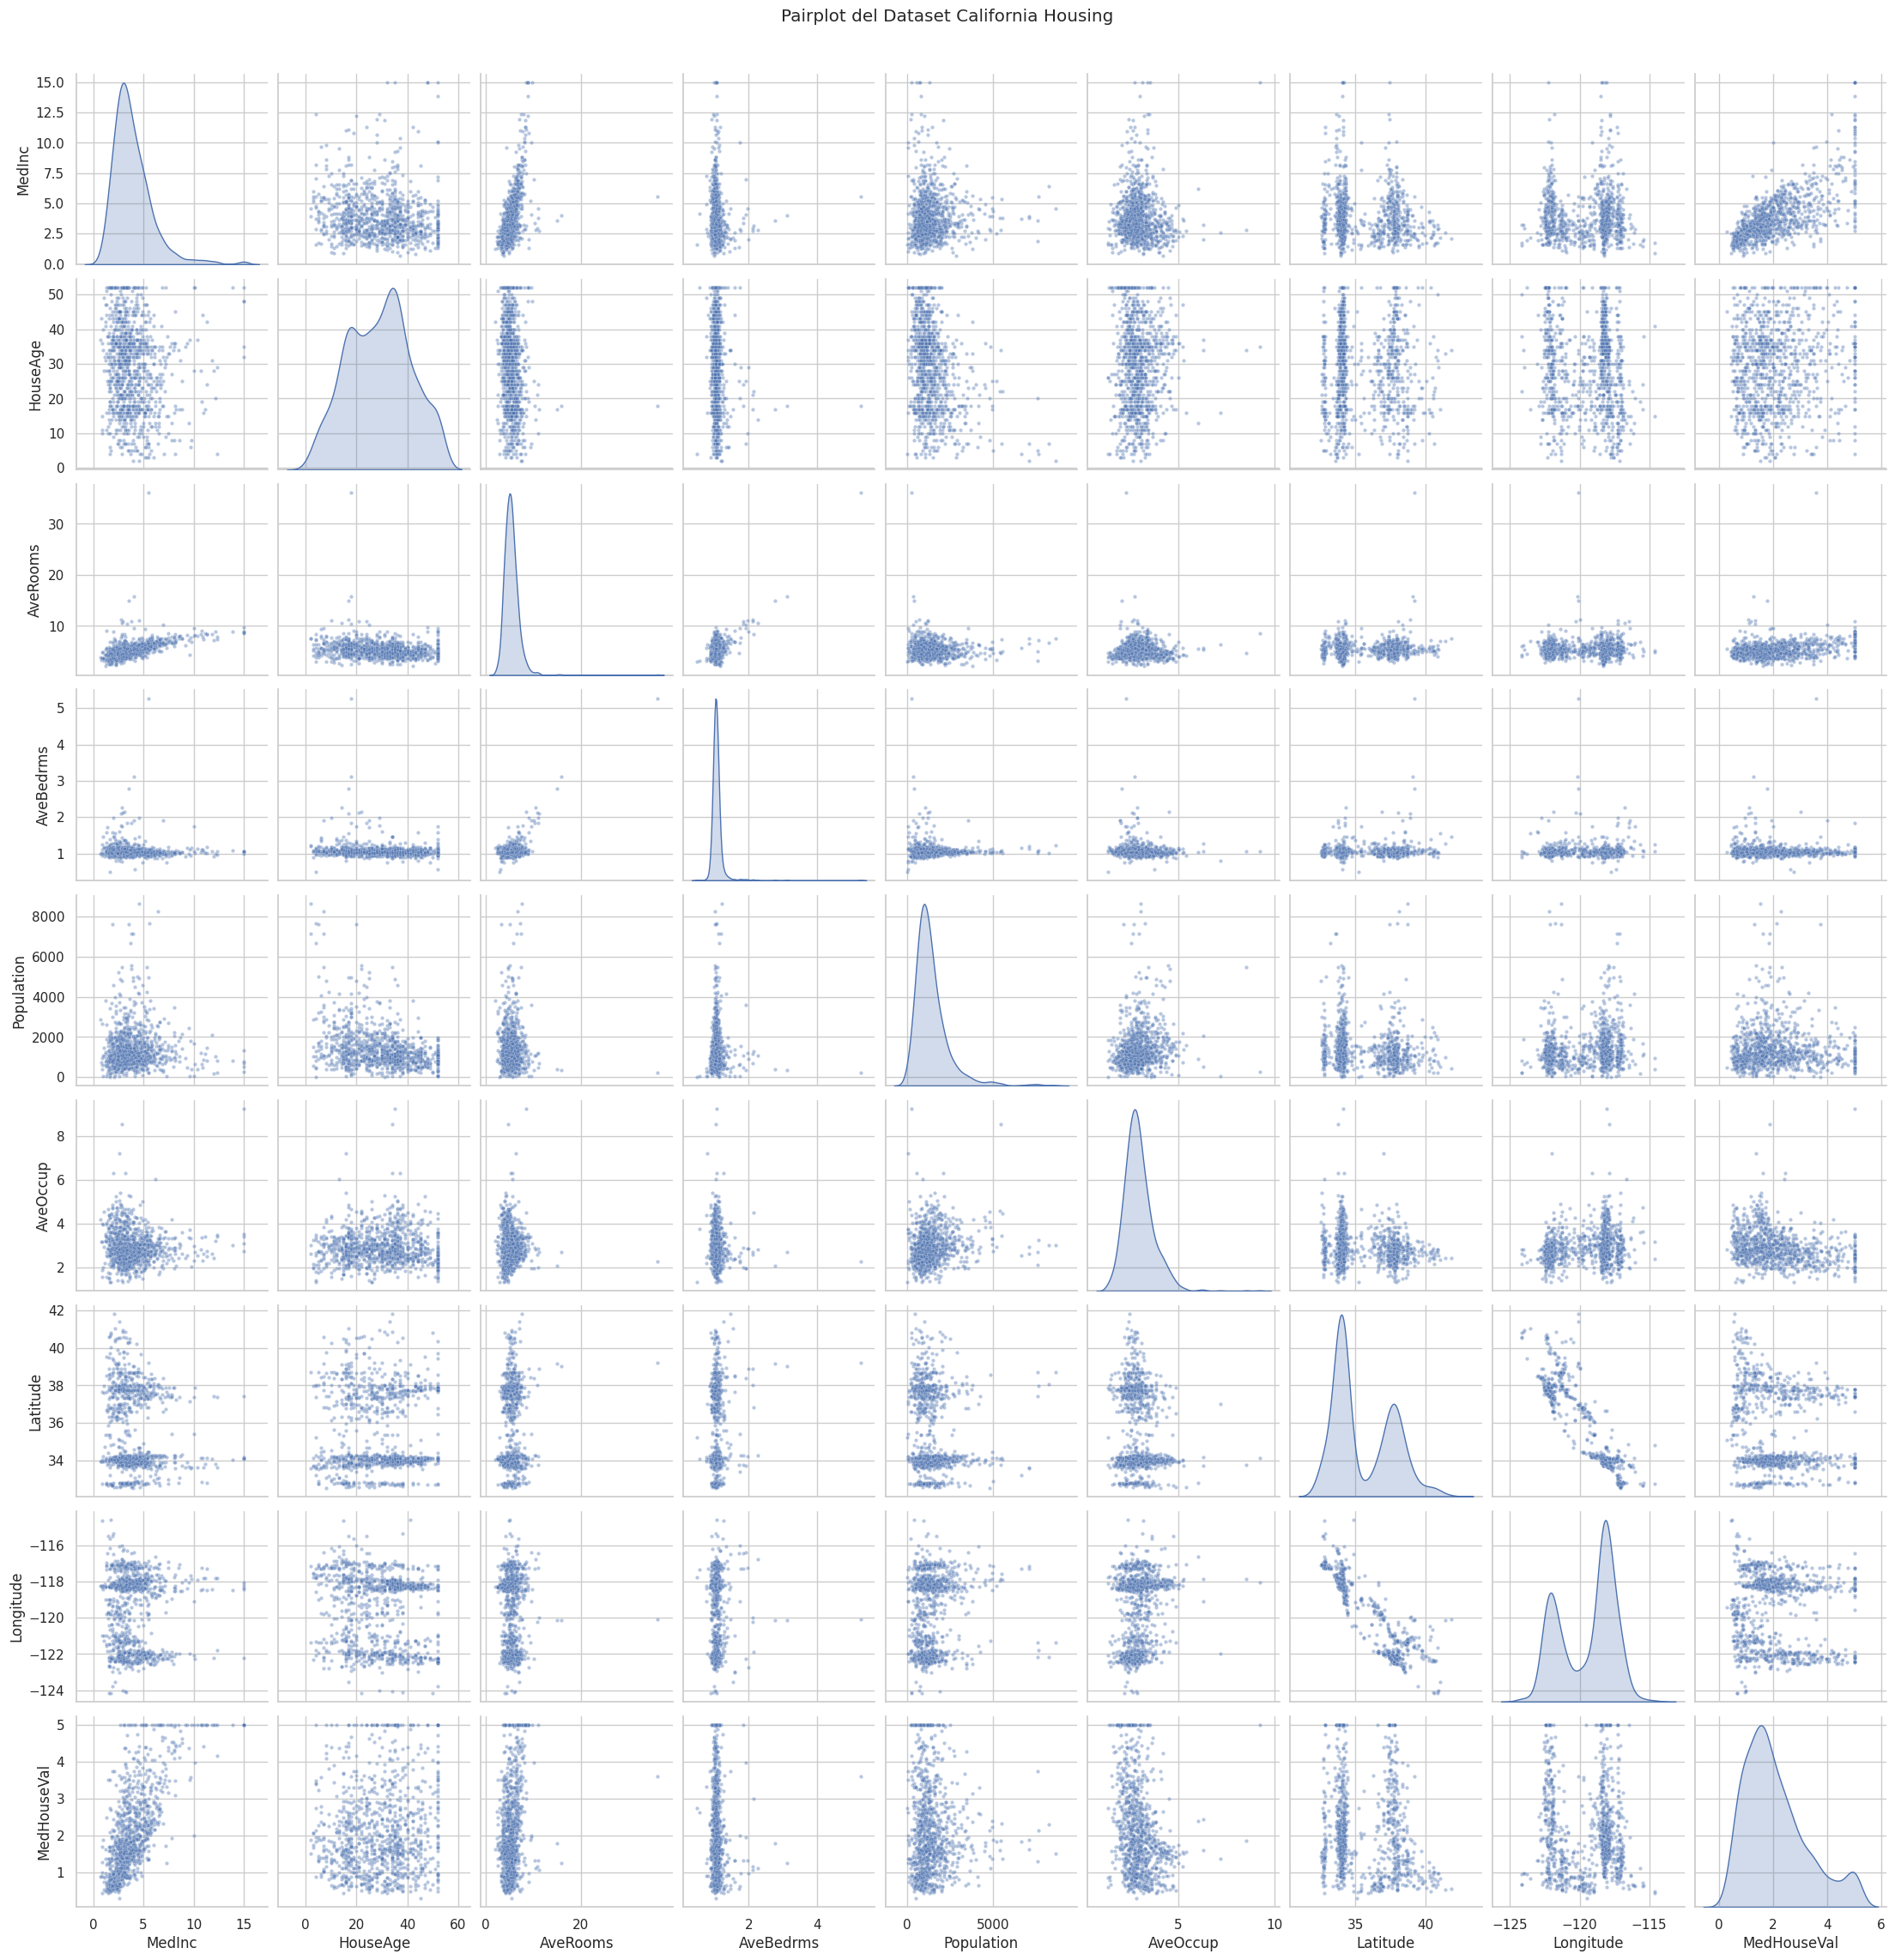

In [10]:
# Campionamento per velocità e chiarezza (es. 1000 righe)
df_sample = df.sample(n=1000, random_state=42)

# Creazione del Pairplot
# 'diag_kind' imposta i grafici sulla diagonale (istogrammi o densità KDE)
# 'plot_kws' serve per rimpicciolire i punti e renderli trasparenti
sns.pairplot(df_sample, 
             diag_kind='kde', 
             plot_kws={'alpha': 0.4, 's': 10})

plt.suptitle("Pairplot del Dataset California Housing", y=1.02)
plt.show()

Da questo grafico noto che

- ho delle variabili lineari tra di loro, sopratutto la variabile target medhouseval 
- ho distribuzioni gaussiane, un po skewed (potrei applicare una trasformazione logaritmica)
- i due picchi di longitude e latitude sono dovuti a San Francisco e Los Angeles

## Cosa devo valutare?

- diagonale con le distribuzioni, controllare che siano gaussiane, controllare skewness e controllare le non gaussiane e capire perché non sono gaussiane
- ho distribuzioni incrociate lineari? Ce ne sono di moooolto lineari? Ci sono cap di valore forzato? (come in medHouseVal) Ci sono distribuzioni più curve? 

## Matrice di Correlazione

### Correlazione di Pearson

Ottima per trovare varibili linearmente dipendenti tra di loro, sono interessanti tutte le correalzioni superiori a + 0.15 e inferiori di - 0.15

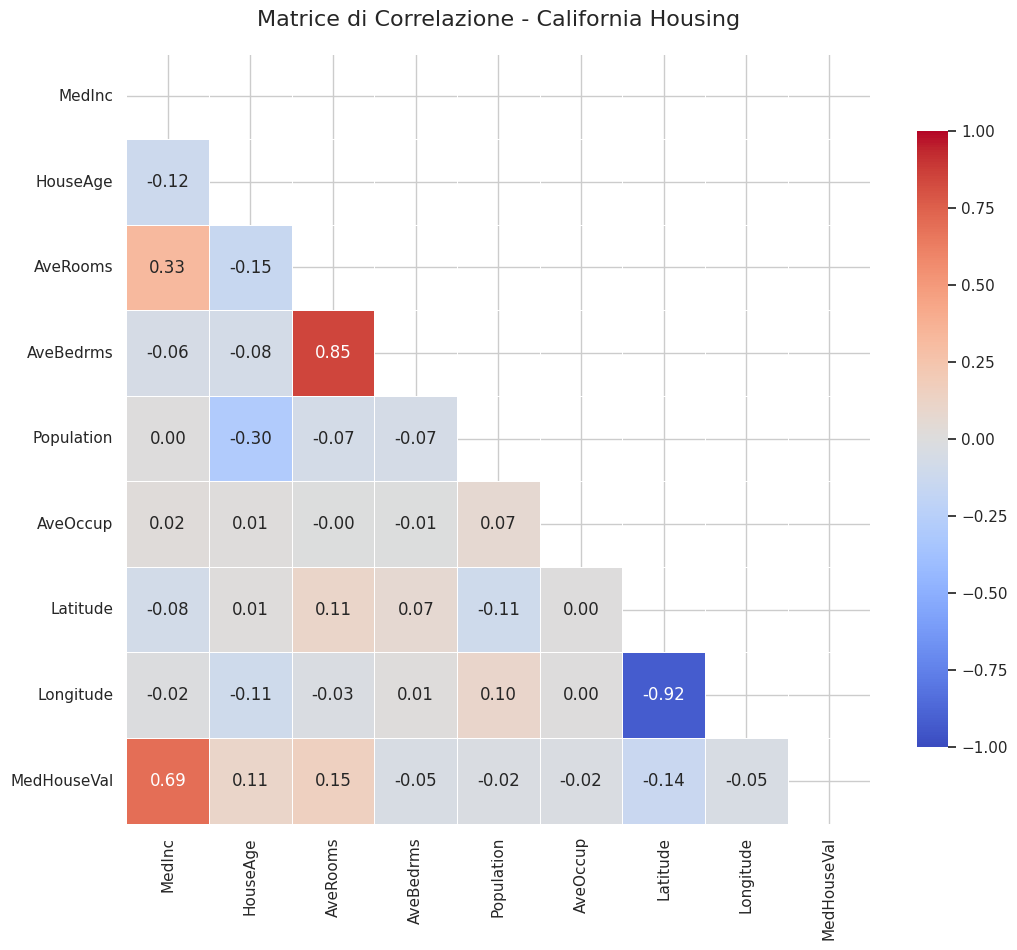

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcolo della matrice di correlazione
# Usiamo il metodo di Pearson (default)
corr = df.corr()

# 2. Creazione di una "maschera" per nascondere la parte superiore
# Essendo la matrice speculare, vedere entrambi i lati crea solo confusione visiva
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Configurazione del grafico
plt.figure(figsize=(12, 10))

# Disegniamo la heatmap
sns.heatmap(
    corr, 
    mask=mask,          # Nasconde la parte superiore duplicata
    annot=True,         # Scrive i numeri dentro i quadratini
    fmt=".2f",          # Formatta i numeri a 2 decimali
    cmap='coolwarm',    # Colore: rosso (positivo), blu (negativo), bianco (zero)
    vmin=-1, vmax=1,    # Imposta i limiti della scala colorata
    center=0,           # Il centro della scala è lo zero
    linewidths=.5,      # Aggiunge una linea di separazione tra i quadrati
    cbar_kws={"shrink": .8} # Rimpicciolisce la barra dei colori laterale
)

plt.title('Matrice di Correlazione - California Housing', fontsize=16, pad=20)
plt.show()

## Ma se avessimo variabili non correlate linearmente o con tanti outlier?

Possiamo usare la correlazione di Spearman che si basa sui ranghi

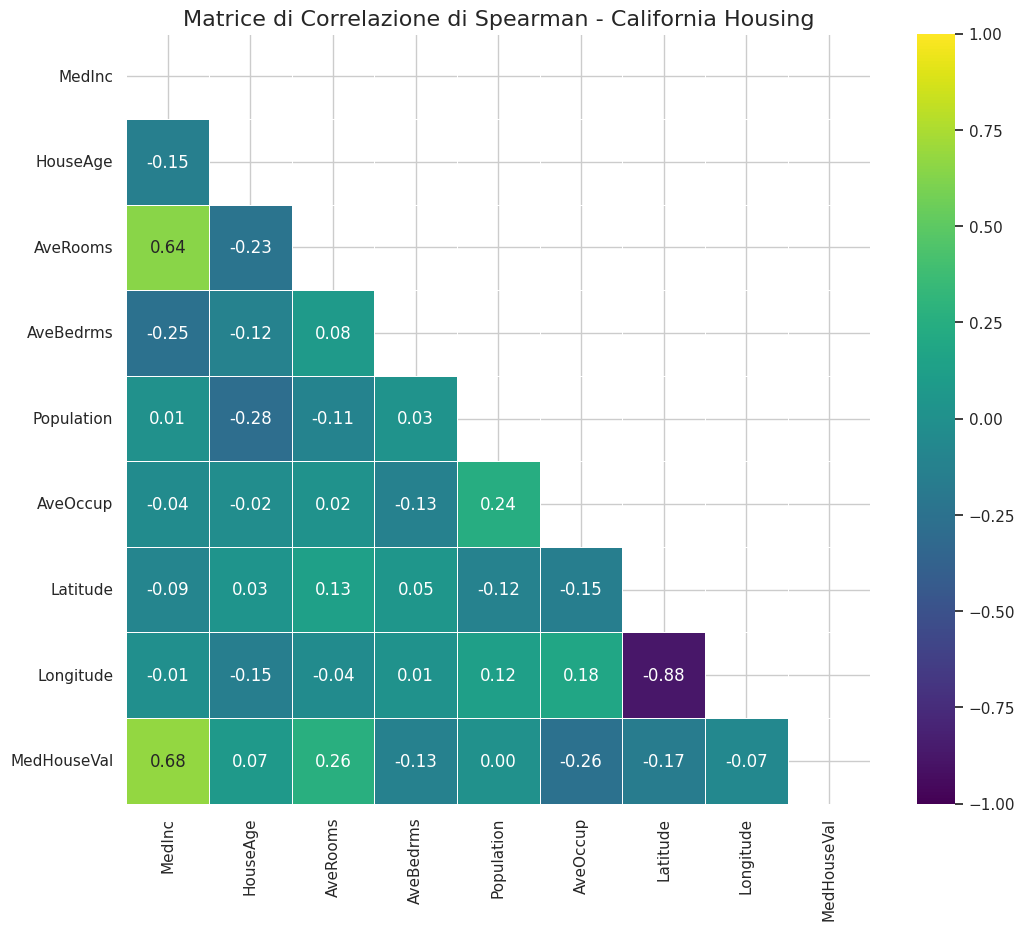

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcolo della matrice di Spearman
# Basta cambiare il parametro 'method'
corr_spearman = df.corr(method='spearman')

# 2. Creazione della maschera (per pulizia visiva)
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

# 3. Visualizzazione
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_spearman, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='viridis',    # Cambio colore per distinguerla dalla Pearson
    vmin=-1, vmax=1, 
    center=0,
    linewidths=.5
)

plt.title('Matrice di Correlazione di Spearman - California Housing', fontsize=16)
plt.show()

## Cosa devo notare?

- ci sono correlazioni fortemente positive o negative?
- hanno senso queste correlazioni? Se m^2 hanno correlazione inversa con il prezzo mi devo fare qualche domanda
- ci sono colonne che ci aspettavamo essere correlate e non lo sono? (mi aspetto che la casa più costi più sia nuova, se la correlazione è 0 o comunque bassa devo capire perché)

## Feature Engineering

Creare nuove feature come combinazioni o modifiche interessanti di feature esistenti:
 - creare raggruppamenti su varibili continue (per house age 1 gruppo ogni 5 anni e vedere se ci sono andamenti o pattern, oppure soglie di valore su medInc per definire ceto basso, medio, ricco e vedere se cambiano alcuni pattern)
 - varibili come divisione di feature esistenti (AveOccup/AveRooms)
 - varibili al quadrato per eventuali relazioni non lineari (da sperman potrei provare a usare ave rooms al quadrato)
 - varibili derivate da consocenza del settore (soprattutto in casi medici, se ho altezza e peso faccio peso/altezza che è un indicatore tecnico medico)

## ATTENZIONE

- di solito le cose più interessanti si ottengono o con raggruppamenti o con divisioni
- raggruppate tutto il possibile e cercate andamenti rispetto alla varibile target (come cambia il prezzo tra case vecchie medie e nuove? Come cambiano le correlazioni interne se seleziono solo le case nuove? Magari ci sono correlazioni che valgono solo per le case nuove e che non potete vedere altrimenti)
- filtrate e stampate tanti grafici in base a categorie che assegnate in base ai raggruppamenti

Correlazione di Spearman con il Target (MedHouseVal):
MedHouseVal         1.000000
Income_Class        0.625628
AveRooms_Squared    0.263367
HouseAge_Group      0.075584
Occup_per_Room     -0.399798
Name: MedHouseVal, dtype: float64


/tmp/ipykernel_56974/2585107523.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Income_Class', y='MedHouseVal', palette='viridis')


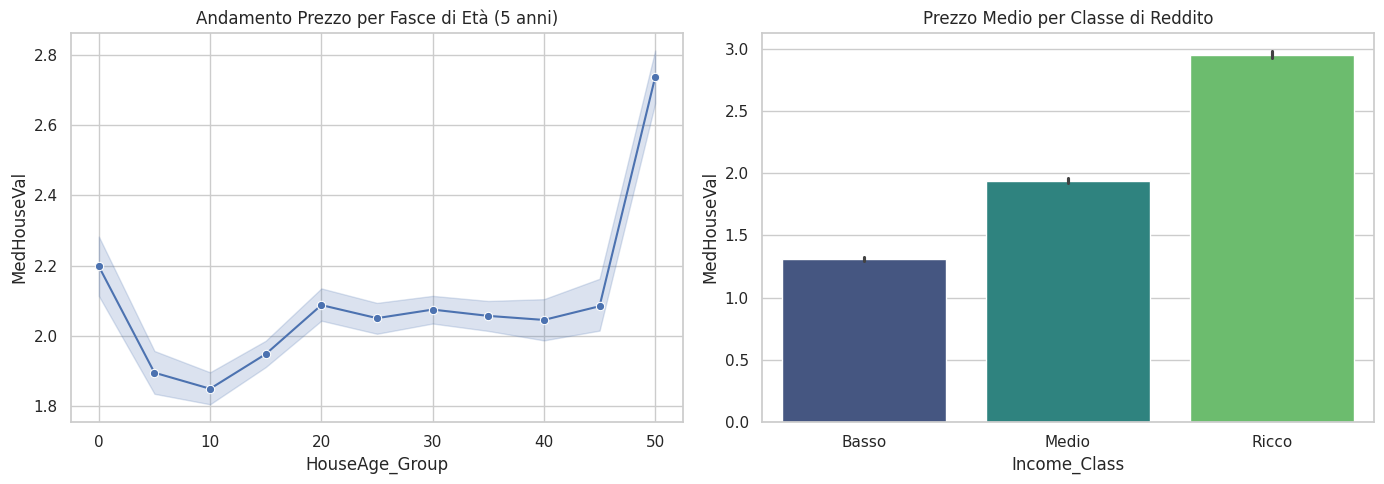

In [13]:
# --- FEATURE ENGINEERING ---

# A. Raggruppamento HouseAge (ogni 5 anni)
# Creiamo etichette numeriche basate sul limite inferiore del gruppo (0, 5, 10...)
df['HouseAge_Group'] = pd.cut(df['HouseAge'], 
                              bins=range(0, 56, 5), 
                              labels=range(0, 55, 5)).astype(float)

# B. Soglie di valore su MedInc (Ceto Basso, Medio, Ricco)
# Usiamo i quartili per definire le classi in modo bilanciato
df['Income_Class'] = pd.qcut(df['MedInc'], q=3, labels=[1, 2, 3]) 
# 1: Basso, 2: Medio, 3: Ricco (manteniamo numerico per la correlazione)

# C. Rapporto tra feature esistenti (Affollamento per stanza)
# Un valore alto indica potenzialmente zone più povere o popolose
df['Occup_per_Room'] = df['AveOccup'] / df['AveRooms']

# D. Variabile al quadrato (Relazione non lineare per AveRooms)
df['AveRooms_Squared'] = df['AveRooms'] ** 2

# --- CALCOLO CORRELAZIONI ---

# Selezioniamo le nuove feature e il target
new_features = ['HouseAge_Group', 'Income_Class', 'Occup_per_Room', 'AveRooms_Squared', 'MedHouseVal']
corr_matrix = df[new_features].astype(float).corr(method='spearman')

print("Correlazione di Spearman con il Target (MedHouseVal):")
print(corr_matrix['MedHouseVal'].sort_values(ascending=False))

# --- VISUALIZZAZIONE PATTERN ---

plt.figure(figsize=(14, 5))

# Plot 1: Andamento Prezzo vs Età Casa (Binned)
plt.subplot(1, 2, 1)
sns.lineplot(data=df, x='HouseAge_Group', y='MedHouseVal', marker='o')
plt.title('Andamento Prezzo per Fasce di Età (5 anni)')

# Plot 2: Prezzo Medio per Classe di Reddito
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='Income_Class', y='MedHouseVal', palette='viridis')
plt.xticks([0, 1, 2], ['Basso', 'Medio', 'Ricco'])
plt.title('Prezzo Medio per Classe di Reddito')

plt.tight_layout()
plt.show()

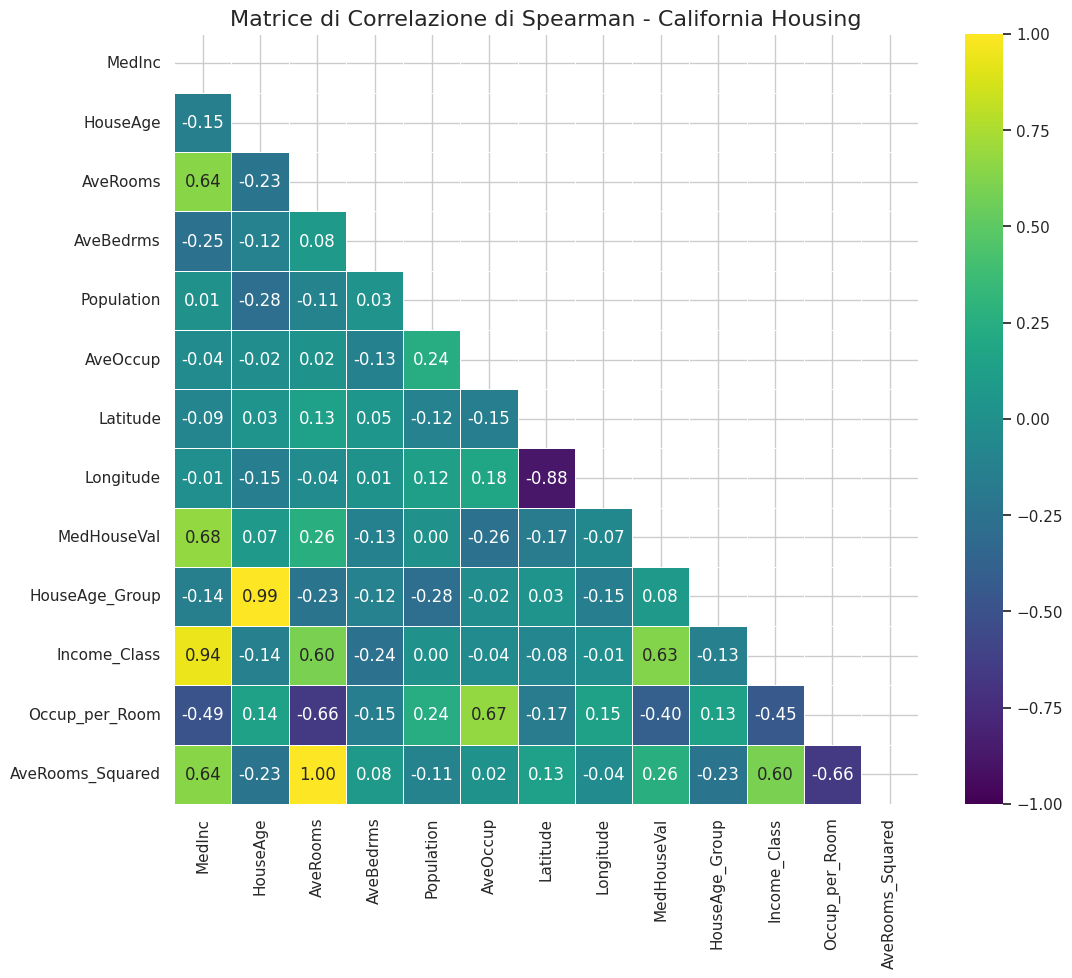

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcolo della matrice di Spearman
# Basta cambiare il parametro 'method'
corr_spearman = df.corr(method='spearman')

# 2. Creazione della maschera (per pulizia visiva)
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

# 3. Visualizzazione
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_spearman, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='viridis',    # Cambio colore per distinguerla dalla Pearson
    vmin=-1, vmax=1, 
    center=0,
    linewidths=.5
)

plt.title('Matrice di Correlazione di Spearman - California Housing', fontsize=16)
plt.show()

## Normalizzazione

Dobbiamo normalizzare i nostri dati per evitare che valori enormi come 5mln per i prezzi vadano ad annientare valori più piccoli come il numero di stanze delle case

Se devo minimizzare un errore e cambiando due valori ottendo

- un errore più basso di 2 punti sul numero di stanze (media 5.5)
- un errore più basso di 1000 euro sul valore di una casa (2 mln)

Il miglior miglioramento, con un approccio relativo è quello sul numero di stanze, ma matematicamente parlando 1000 è meglio di 2, dobbiamo evitare questa confusione ai nostri modelli

### 1. MinMaxScaler (Normalizzazione)

Trasforma i dati in un intervallo fisso, solitamente **[0, 1]**.


$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

* **Pro:** Mantiene esattamente la relazione tra i dati.
* **Contro:** È **estremamente sensibile agli outlier**. Se hai un solo valore enorme (es. una casa con 100 stanze), schiaccerà tutti gli altri valori vicini allo zero.

### 2. StandardScaler (Standardizzazione)

Trasforma i dati in modo che abbiano **Media = 0** e **Deviazione Standard = 1**.


$$z = \frac{x - \mu}{\sigma}$$

* **Pro:** È più robusto in presenza di outlier rispetto al Min-Max e rende i coefficienti dei modelli lineari più facili da interpretare.
* **Contro:** Non garantisce un range fisso (i valori possono andare oltre -3 o +3).

Tranne rare eccezioni di base si usa sempre lo standardScaler

In [15]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.datasets import fetch_california_housing

# 1. Prepariamo i dati
data = fetch_california_housing(as_frame=True)
X = data.frame[['MedInc', 'HouseAge', 'Population']] # Prendiamo 3 variabili con scale diverse

# 2. Inizializziamo gli Scaler
min_max = MinMaxScaler()
standard = StandardScaler()

# 3. Trasformazione
X_minmax = min_max.fit_transform(X)
X_standard = standard.fit_transform(X)

# Creiamo un DataFrame per confrontare i risultati sulla prima riga
comparison = pd.DataFrame({
    'Originale': X.iloc[0],
    'Min-Max [0, 1]': X_minmax[0],
    'Standard (z-score)': X_standard[0]
})

print("Confronto Scaler sulla prima riga del dataset:")
print(comparison)

Confronto Scaler sulla prima riga del dataset:
            Originale  Min-Max [0, 1]  Standard (z-score)
MedInc         8.3252        0.539668            2.344766
HouseAge      41.0000        0.784314            0.982143
Population   322.0000        0.008941           -0.974429


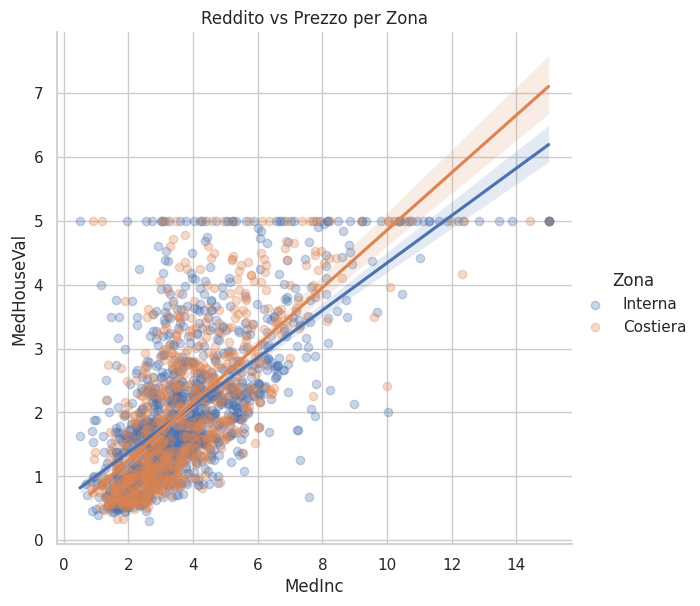

In [16]:
"""
Il reddito medio (MedInc) sembra il predittore più forte.
Ma un reddito alto in una zona desertica vale quanto lo stesso reddito a San Francisco?
Quale altra variabile potresti 'mescolare' con il reddito per capire meglio la capacità di acquisto in quella zona?
"""

"""
spiegami questa domanda
La domanda si riferisce al fatto che il reddito medio (MedInc) è un indicatore importante per prevedere il valore delle case,
ma da solo potrebbe non raccontare tutta la storia.
Ad esempio, un reddito alto in una zona desertica potrebbe non tradursi in un alto valore delle case,
mentre lo stesso reddito a San Francisco potrebbe essere associato a case molto costose.
Quindi, la domanda chiede di pensare a quale altra variabile potrebbe essere combinata con il reddito per avere una 
visione più completa della capacità di acquisto in quella zona.
Una possibile variabile da considerare potrebbe essere la "Population" (popolazione).
Se una zona ha un reddito medio alto ma anche una popolazione molto alta, potrebbe indicare una maggiore domanda di case, 
il che potrebbe aumentare i prezzi.
Al contrario, una zona con un reddito medio alto ma una popolazione bassa potrebbe non avere la stessa pressione sui prezzi delle case.

Esempio di combinazione: "Reddito Medio x Popolazione"
Potremmo creare una nuova variabile che moltiplica il reddito medio per la popolazione,
per vedere se le zone con un alto reddito e una grande popolazione tendono ad avere case più costose.
"""

# red_molt_pop = df['MedInc'] * df['Population']
# corr_red_molt_pop = red_molt_pop.corr(df['MedHouseVal'], method='spearman')
# print(f"Correlazione di Spearman tra Reddito Medio x Popolazione e Valore delle Case: {corr_red_molt_pop:.2f}")

# sns.scatterplot(x=red_molt_pop, y=df['MedHouseVal'], alpha=0.5)
# plt.title('Reddito Medio x Popolazione vs Valore delle Case')
# plt.xlabel('Reddito Medio x Popolazione')
# plt.ylabel('Valore delle Case')
# plt.show()

df["Zona"] = df["Longitude"].apply(lambda x: "Costiera" if x < -120 else "Interna")

sns.lmplot(
    data=df.sample(2000, random_state=42),
    x="MedInc",
    y="MedHouseVal",
    hue="Zona",
    scatter_kws={"alpha":0.3},
    height=6
)

plt.title("Reddito vs Prezzo per Zona")
plt.show()

In [17]:
#Funzione Haversine
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Raggio medio della Terra in km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

Correlazione con Latitude: -0.14416027687465927
Correlazione con Dist_Citta_Piu_Vicina: -0.4334561113690452


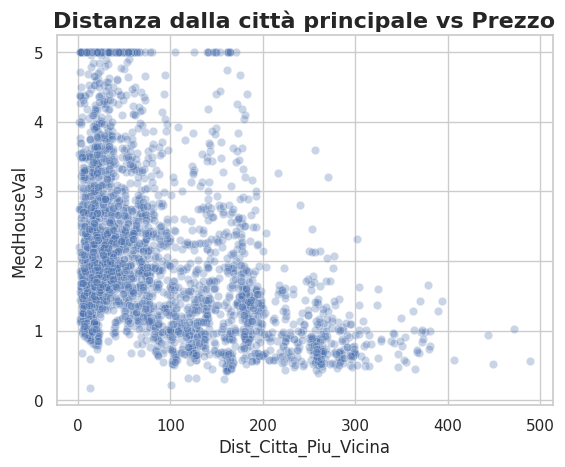

In [28]:
#Coordinate città
sf_lat, sf_lon = 37.7749, -122.4194
la_lat, la_lon = 34.0522, -118.2437

#Distanze
df["Dist_SF"] = haversine(df["Latitude"], df["Longitude"], sf_lat, sf_lon)
df["Dist_LA"] = haversine(df["Latitude"], df["Longitude"], la_lat, la_lon)

#Distanza dal polo più vicino
df["Dist_Citta_Piu_Vicina"] = df[["Dist_SF", "Dist_LA"]].min(axis=1)
print("Correlazione con Latitude:",
      df["Latitude"].corr(df["MedHouseVal"]))

print("Correlazione con Dist_Citta_Piu_Vicina:",
      df["Dist_Citta_Piu_Vicina"].corr(df["MedHouseVal"]))

# cosa facciamo ora? vogliamo vedere se c'è un pattern tra distanza dalla città più vicina e prezzo?
# aggiungiamo un boxplot per vedere la distribuzione dei prezzi in base alla distanza dalla città più vicina
# mi spiego meglio: voglio vedere se le case più vicine a SF o LA tendono ad avere prezzi più alti,
#e se c'è una tendenza generale che mostra come il prezzo diminuisce all'aumentare della distanza dalla città più vicina
# con un grafico lineare o scatterplot
sns.scatterplot(
    data=df.sample(3000, random_state=42),
    x="Dist_Citta_Piu_Vicina",
    y="MedHouseVal",
    alpha=0.3
)

plt.title(fontdict={'fontsize': 16, 'fontweight': 'bold'}, label= "Distanza dalla città principale vs Prezzo")
plt.show()

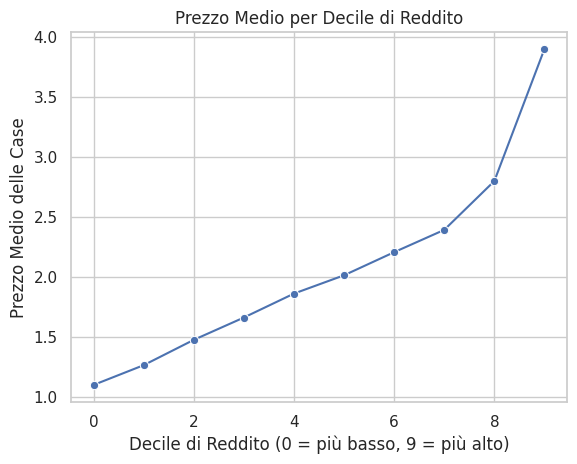

   Reddito_Decile      mean     min      max
0               0  1.515145  0.4999   1.9038
1               1  2.139838  1.9041   2.3523
2               2  2.557075  2.3526   2.7401
3               3  2.955537  2.7404   3.1406
4               4  3.326199  3.1410   3.5347
5               5  3.732804  3.5349   3.9667
6               6  4.182009  3.9673   4.4375
7               7  4.763660  4.4387   5.1097
8               8  5.577262  5.1098   6.1592
9               9  7.959844  6.1593  15.0001


In [30]:
"""
Se dividete il reddito in 10 gruppi (decili), il prezzo delle case sale sempre della stessa quantità
tra un gruppo e l'altro? O c'è un punto in cui, anche se il reddito raddoppia,
il prezzo della casa smette di salire drasticamente?
"""
# fare un binning sui redditi e stampare la media del prezzo per ogni bin, poi fare un grafico a linee per vedere se c'è un punto di rottura
df["Reddito_Decile"] = pd.qcut(df["MedInc"], q=10, labels=False)
reddito_prezzo = df.groupby("Reddito_Decile")["MedHouseVal"].mean().reset_index()
sns.lineplot(data=reddito_prezzo, x="Reddito_Decile", y="MedHouseVal", marker='o')
plt.title("Prezzo Medio per Decile di Reddito")
plt.xlabel("Decile di Reddito (0 = più basso, 9 = più alto)")
plt.ylabel("Prezzo Medio delle Case")
plt.show()

#controlliamo gli outlier nei decili più alti, stampiamo la media dell'income di ogni bin
reddito_decile_stats = df.groupby("Reddito_Decile")["MedInc"].agg(['mean', 'min', 'max']).reset_index()
print(reddito_decile_stats)

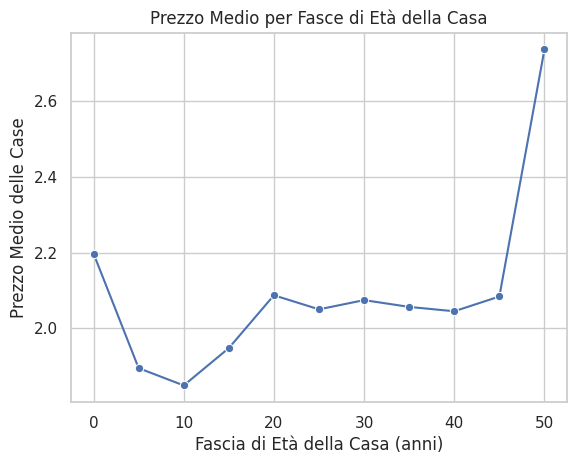

    Età_Casa_Bin       mean   min   max
0            0.0   4.096601   1.0   5.0
1            5.0   8.235644   6.0  10.0
2           10.0  13.401630  11.0  15.0
3           15.0  17.731204  16.0  20.0
4           20.0  23.136500  21.0  25.0
5           25.0  27.875547  26.0  30.0
6           30.0  33.271660  31.0  35.0
7           35.0  37.479319  36.0  40.0
8           40.0  42.990402  41.0  45.0
9           45.0  47.683146  46.0  50.0
10          50.0  51.963664  51.0  52.0


In [32]:
"""
Ci aspetteremmo che le case più vecchie costino meno.
Ma se create dei bin per l'età, i prezzi medi seguono davvero una linea discesa?
O c'è un 'ritorno di fiamma' dove le case molto vecchie tornano a costare tanto quanto quelle nuove?
"""
df["Età_Casa_Bin"] = pd.cut(df["HouseAge"], bins=range(0, 56, 5), labels=range(0, 55, 5)).astype(float)
eta_prezzo = df.groupby("Età_Casa_Bin")["MedHouseVal"].mean().reset_index()
sns.lineplot(data=eta_prezzo, x="Età_Casa_Bin", y="MedHouseVal", marker='o')
plt.title("Prezzo Medio per Fasce di Età della Casa")
plt.xlabel("Fascia di Età della Casa (anni)")
plt.ylabel("Prezzo Medio delle Case")
plt.show()

#controllo degli outlier nelle case più vecchie, stampiamo la media dell'età di ogni bin
eta_casa_bin_stats = df.groupby("Età_Casa_Bin")["HouseAge"].agg(['mean', 'min', 'max']).reset_index()
print(eta_casa_bin_stats)

    Lat_Cella  Lon_Cella  MedHouseVal
0          33       -118     3.283148
1          33       -117     1.970557
2          33       -116     0.762039
3          33       -115     0.745192
4          34       -120     3.312366
5          34       -119     2.835985
6          34       -118     2.371207
7          34       -117     1.249314
8          34       -116     1.195238
9          34       -115     0.811067
10         34       -114     0.781667
11         35       -121     2.187222
12         35       -120     1.800718
13         35       -119     0.837827
14         35       -118     1.314810
15         35       -117     0.848797
16         35       -116     0.575000
17         35       -115     0.602143
18         36       -122     3.378001
19         36       -121     1.660320
20         36       -120     0.767132
21         36       -119     0.776884
22         36       -118     0.831333
23         36       -117     0.276995
24         36       -116     0.502000
25         3

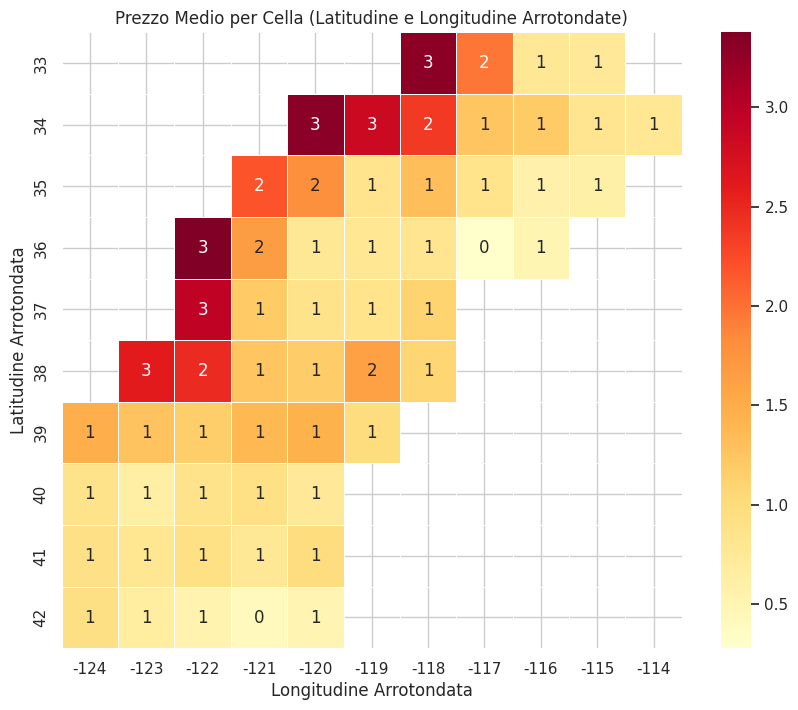

In [36]:
"""
Arrotondate la latitudine e la longitudine all'intero più vicino.
Ora calcolate il prezzo medio per ogni 'cella' della scacchiera.
Quali celle sono dei deserti economici e quali sono miniere d'oro?
Ci sono celle vicine con prezzi opposti?
"""
#calcolo della cella della scacchiera basata su latitudine e longitudine arrotondate
df["Lat_Cella"] = df["Latitude"].round(0).astype(int)
df["Lon_Cella"] = df["Longitude"].round(0).astype(int)
prezzo_medio_per_cella = df.groupby(["Lat_Cella", "Lon_Cella"])["MedHouseVal"].mean().reset_index()
print(prezzo_medio_per_cella)

#creazione di una heatmap per visualizzare i prezzi medi per cella
pivot_table = prezzo_medio_per_cella.pivot(index="Lat_Cella", columns="Lon_Cella", values="MedHouseVal")
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, cmap="YlOrRd", annot=True, fmt=".0f", linewidths=.5)
plt.title("Prezzo Medio per Cella (Latitudine e Longitudine Arrotondate)")
plt.xlabel("Longitudine Arrotondata")
plt.ylabel("Latitudine Arrotondata")
plt.show()

/tmp/ipykernel_56974/2983850315.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=occup_prezzo, x="Occup_Bin", y="MedHouseVal", palette="viridis")


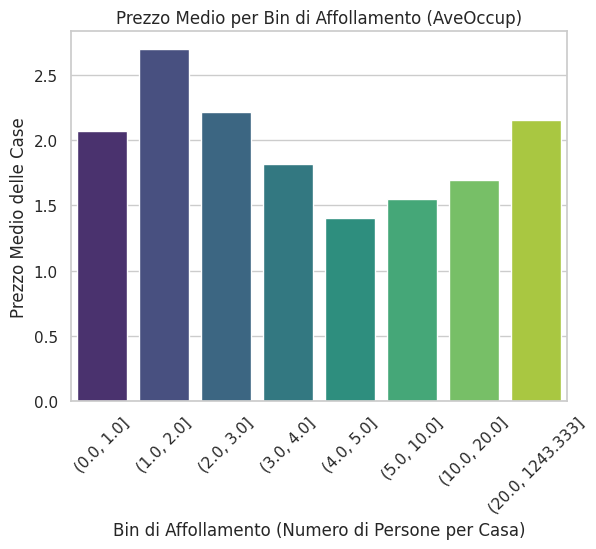

          Occup_Bin        mean        min          max
0        (0.0, 1.0]    0.804299   0.692308     0.970588
1        (1.0, 2.0]    1.773924   1.060606     2.000000
2        (2.0, 3.0]    2.566185   2.000805     3.000000
3        (3.0, 4.0]    3.373242   3.000898     4.000000
4        (4.0, 5.0]    4.376182   4.003120     5.000000
5       (5.0, 10.0]    5.818116   5.001062     9.954545
6      (10.0, 20.0]   13.985302  10.153846    19.312500
7  (20.0, 1243.333]  287.050356  21.333333  1243.333333


In [38]:
"""
C'è una relazione tra quanto è 'affollata' una casa e il suo valore?
Provate a vedere il prezzo medio per i bin di AveOccup. Notate dei valori estremi (bin con 20+ persone)?
"""
bins_occup = [0, 1, 2, 3, 4, 5, 10, 20, df["AveOccup"].max()]
df["Occup_Bin"] = pd.cut(df["AveOccup"], bins=bins_occup)
occup_prezzo = df.groupby("Occup_Bin")["MedHouseVal"].mean().reset_index()
sns.barplot(data=occup_prezzo, x="Occup_Bin", y="MedHouseVal", palette="viridis")
plt.title("Prezzo Medio per Bin di Affollamento (AveOccup)")
plt.xlabel("Bin di Affollamento (Numero di Persone per Casa)")
plt.ylabel("Prezzo Medio delle Case")
plt.xticks(rotation=45)
plt.show()

#verifico se ci sono valori estremi nei bin di affollamento
occup_bin_stats = df.groupby("Occup_Bin")["AveOccup"].agg(['mean', 'min', 'max']).reset_index()
print(occup_bin_stats)

In [39]:
"""
C'è un altro istogramma, oltre a quello del prezzo, che si interrompe bruscamente con un picco finale.
Quale?
Cosa succede a una casa che ha 53 o 60 anni in questo dataset?
Viene registrata correttamente o finisce in un 'calderone' comune?
Il problema é Pisciotta o LA?
"""
print(df["HouseAge"].value_counts().sort_index())

HouseAge
1.0        4
2.0       58
3.0       62
4.0      191
5.0      244
6.0      160
7.0      175
8.0      206
9.0      205
10.0     264
11.0     254
12.0     238
13.0     302
14.0     412
15.0     512
16.0     771
17.0     698
18.0     570
19.0     502
20.0     465
21.0     446
22.0     399
23.0     448
24.0     478
25.0     566
26.0     619
27.0     488
28.0     471
29.0     461
30.0     476
31.0     458
32.0     565
33.0     615
34.0     689
35.0     824
36.0     862
37.0     537
38.0     394
39.0     369
40.0     304
41.0     296
42.0     368
43.0     353
44.0     356
45.0     294
46.0     245
47.0     198
48.0     177
49.0     134
50.0     136
51.0      48
52.0    1273
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

"""
Sappiamo che San Francisco e Los Angeles sono i poli economici.
Se calcolaste la distanza di ogni casa dal centro di queste due città,
pensate che questa 'nuova coordinata' spiegherebbe il prezzo meglio della semplice latitudine?
"""
# cosa ci consigli di fare ora? vogliamo vedere se la distanza dalla città più vicina spiega meglio il prezzo rispetto alla latitudine?
# possiamo calcolare la correlazione di Spearman tra il prezzo e la latitudine, e poi tra il prezzo e la distanza dalla città più vicina, per vedere quale delle due variabili ha una correlazione più forte con il prezzo delle case
"""
cosa é il metodo di Spearman?
è un metodo di correlazione non parametrico che misura la forza e la direzione dell'associazione monotona 
tra due variabili. A differenza del metodo di Pearson, che misura la correlazione lineare, 
il metodo di Spearman si basa sui ranghi dei dati e può catturare relazioni non lineari.
Se la correlazione di Spearman è più alta per la distanza dalla città più vicina rispetto alla latitudine,
potrebbe indicare che la distanza è un predittore più forte del prezzo delle case rispetto alla latitudine.
"""

#PT1: Calcolo della correlazione di Spearman
corr_latitude = df["Latitude"].corr(df["MedHouseVal"], method='spearman')
corr_dist_citta = df["Dist_Citta_Piu_Vicina"].corr(df["MedHouseVal"], method='spearman')
print(f"Correlazione di Spearman tra Latitude e MedHouseVal: {corr_latitude:.2f}")
print(f"Correlazione di Spearman tra Distanza dalla Città più Vicina e MedHouseVal: {corr_dist_citta:.2f}")

#PT2: Regressione Lineare per confrontare R²
X1 = df[["Latitude"]]
X2 = df[["Dist_Citta_Piu_Vicina"]]
y = df["MedHouseVal"]

model1 = LinearRegression().fit(X1, y)
model2 = LinearRegression().fit(X2, y)
# cosa ci rapprsenta l'R² in questo contesto?
"""
L'R², o coefficiente di determinazione,
rappresenta la proporzione della varianza nel target (MedHouseVal) che è spiegata dalle feature
(Latitude o Distanza dalla Città più Vicina) nel modello di regressione lineare.
Un R² più alto indica che la feature spiega meglio la variabilità del prezzo delle case.
Se l'R² per la distanza dalla città più vicina è significativamente più alto di quello per la latitudine,
potrebbe suggerire che la distanza è un predittore più forte del prezzo delle case rispetto alla latitudine.
"""
print("R² Latitude:", model1.score(X1, y))
print("R² Distanza:", model2.score(X2, y))

Correlazione di Spearman tra Latitude e MedHouseVal: -0.17
Correlazione di Spearman tra Distanza dalla Città più Vicina e MedHouseVal: -0.45
R² Latitude: 0.020782185428578237
R² Distanza: 0.187884200483174



# NO
__NO__
`30L`

Occup_Bin
(0.0, 1.0]              3
(1.0, 2.0]           1648
(2.0, 3.0]          11001
(3.0, 4.0]           6247
(4.0, 5.0]           1396
(5.0, 10.0]           308
(10.0, 20.0]           27
(20.0, 1243.333]       10
Name: count, dtype: int64


/tmp/ipykernel_56974/3969362184.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Occup_Bin", y="MedHouseVal", palette="viridis")


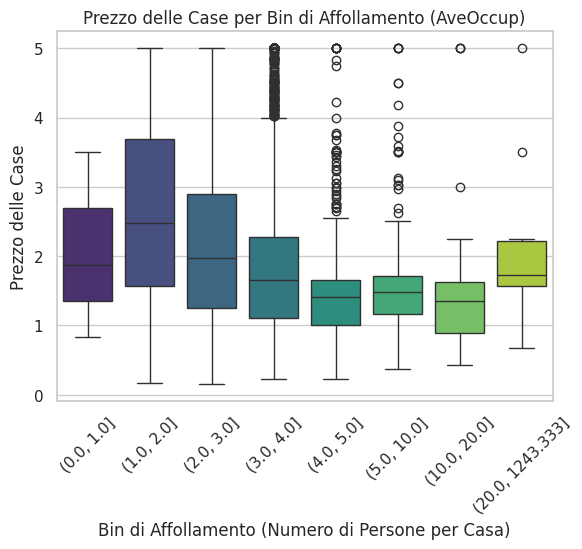

In [ ]:
"""
Se una casa ha un AveOccup di 1.5 persone e un'altra di 6 persone,
quale vi aspettereste che costi di più?
Ora verificate nei dati:
la vostra intuizione regge o i dati vi stanno dicendo che troppa gente in poco spazio 'affonda' il valore dell'immobile?
"""

value_counts = df["Occup_Bin"].value_counts().sort_index()
print(value_counts)

#creiamo un boxplot per vedere la distribuzione dei prezzi in base al bin di affollamento
sns.boxplot(data=df, x="Occup_Bin", y="MedHouseVal", palette="viridis")
plt.title("Prezzo delle Case per Bin di Affollamento (AveOccup)")
plt.xlabel("Bin di Affollamento (Numero di Persone per Casa)")
plt.ylabel("Prezzo delle Case")
plt.xticks(rotation=45)
plt.show()

"""
quindi la nostra intuizione è corretta: 
le case con un AveOccup di 1.5 persone tendono ad avere prezzi più alti rispetto a quelle con un AveOccup di 6 persone,
suggerendo che un eccessivo affollamento può diminuire il valore dell'immobile.
"""